# Proyek Akhir Data Mining

## Preprocessing dan Unsupervised Learning (K-Means Clustering)

**Nama : Abdallah Najwan Muharidien**

**NIM : 241011400767**

**Kelas : 04TPLM008**

In [ ]:
#IMPORT LIBRARY

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [ ]:
# ======================================
# MEMBACA DATASET 5 PERTAMA
# ======================================

df = pd.read_csv("dataset/marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
# ======================================
# MENAMPILKAN 5 DATA TERAKHIR
# ======================================

df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [7]:
# ======================================
# INFORMASI DATASET
# ======================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [8]:
# ======================================
# STATISTIK DESKRIPTIF
# ======================================

df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [12]:
# ======================================
# MENAMPILKAN NAMA KOLOM
# ======================================

print("Daftar Nama Kolom:\n")

for i, kolom in enumerate(df.columns, start=1):
    print(f"{i}. {kolom}")

Daftar Nama Kolom:

1. ID
2. Year_Birth
3. Education
4. Marital_Status
5. Income
6. Kidhome
7. Teenhome
8. Dt_Customer
9. Recency
10. MntWines
11. MntFruits
12. MntMeatProducts
13. MntFishProducts
14. MntSweetProducts
15. MntGoldProds
16. NumDealsPurchases
17. NumWebPurchases
18. NumCatalogPurchases
19. NumStorePurchases
20. NumWebVisitsMonth
21. AcceptedCmp3
22. AcceptedCmp4
23. AcceptedCmp5
24. AcceptedCmp1
25. AcceptedCmp2
26. Complain
27. Z_CostContact
28. Z_Revenue
29. Response


In [13]:
# ==========================================================
# UKURAN DATASET
# ==========================================================

baris, kolom = df.shape

print(f"Jumlah Baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

Jumlah Baris : 2240
Jumlah Kolom : 29


In [14]:
# ==========================================================
# MENGECEK MISSING VALUE
# ==========================================================
# Menampilkan jumlah data kosong
# pada setiap kolom.
# ==========================================================

missing_value = df.isnull().sum()

print(missing_value)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


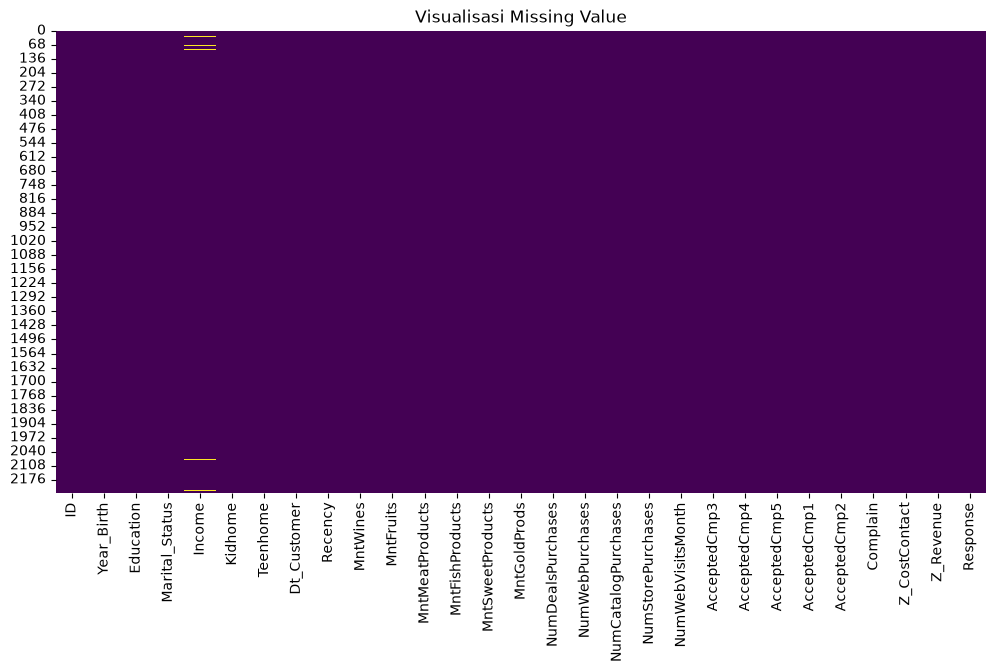

In [15]:
# ==========================================================
# VISUALISASI MISSING VALUE
# ==========================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Visualisasi Missing Value")

plt.show()

In [16]:
# ==========================================================
# MENANGANI MISSING VALUE
# ==========================================================
# Mengisi nilai kosong pada kolom Income
# menggunakan nilai rata-rata.
# ==========================================================

df["Income"] = df["Income"].fillna(df["Income"].mean())

print("✓ Missing Value berhasil ditangani.")

✓ Missing Value berhasil ditangani.


In [17]:
# ==========================================================
# CEK ULANG MISSING VALUE
# ==========================================================

df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [18]:
# ==========================================================
# MENGECEK DATA DUPLIKAT
# ==========================================================

jumlah_duplikat = df.duplicated().sum()

print(f"Jumlah Data Duplikat : {jumlah_duplikat}")

Jumlah Data Duplikat : 0


In [19]:
# ==========================================================
# MENGHAPUS DATA DUPLIKAT
# ==========================================================

df.drop_duplicates(inplace=True)

print("✓ Data duplikat berhasil dihapus.")

✓ Data duplikat berhasil dihapus.


In [25]:
# ==========================================================
# CEK ULANG DATA DUPLIKAT
# ==========================================================

print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 0


In [20]:
# ==========================================================
# UKURAN DATASET SETELAH CLEANING
# ==========================================================

print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Baris : 2240
Jumlah Kolom : 29


In [21]:
# ==========================================================
# MEMILIH FITUR
# ==========================================================
# Memilih atribut numerik yang akan digunakan
# pada proses clustering.
# ==========================================================

fitur = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

X = df[fitur]

In [22]:
# ==========================================================
# MENAMPILKAN FITUR YANG DIGUNAKAN
# ==========================================================

X.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,58138.0,0,0,58,635,88,546,172,88,88,8,10,4,7
1,46344.0,1,1,38,11,1,6,2,1,6,1,1,2,5
2,71613.0,0,0,26,426,49,127,111,21,42,8,2,10,4
3,26646.0,1,0,26,11,4,20,10,3,5,2,0,4,6
4,58293.0,1,0,94,173,43,118,46,27,15,5,3,6,5


In [23]:
# ==========================================================
# NORMALISASI DATA
# ==========================================================
# Menggunakan StandardScaler agar setiap
# atribut memiliki skala yang sama.
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✓ Normalisasi data berhasil.")

✓ Normalisasi data berhasil.


In [24]:
# ==========================================================
# HASIL NORMALISASI
# ==========================================================

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,1.409304,2.510890,-0.550785,0.693904
1,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-1.110409,-0.568720,-1.166125,-0.130463
2,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,1.409304,-0.226541,1.295237,-0.542647
3,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.750450,-0.910898,-0.550785,0.281720
4,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,0.329427,0.115638,0.064556,-0.130463


In [28]:
# ==========================================================
# MENENTUKAN JUMLAH CLUSTER (ELBOW METHOD)
# ==========================================================
# Menggunakan metode Elbow untuk menentukan
# jumlah cluster terbaik.
# ==========================================================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

print("✓ Perhitungan Elbow selesai.")

✓ Perhitungan Elbow selesai.


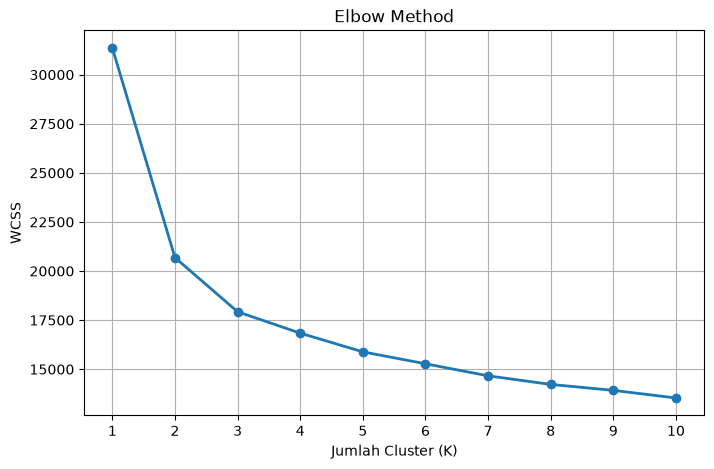

In [29]:
# ==========================================================
# VISUALISASI ELBOW METHOD
# ==========================================================
# Menampilkan grafik Elbow untuk menentukan
# jumlah cluster terbaik.
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss, marker="o", linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")

plt.xticks(range(1,11))
plt.grid(True)

plt.show()

In [30]:
# ==========================================================
# MEMBANGUN MODEL K-MEANS
# ==========================================================
# Menggunakan jumlah cluster sebanyak 3.
# ==========================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_scaled)

print("✓ Model K-Means berhasil dibuat.")

✓ Model K-Means berhasil dibuat.


In [31]:
# ==========================================================
# MENAMBAHKAN LABEL CLUSTER KE DATASET
# ==========================================================

df["Cluster"] = cluster

print("✓ Label cluster berhasil ditambahkan.")

df.head()

✓ Label cluster berhasil ditambahkan.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,0,3,11,1,2
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,0,3,11,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,0,3,11,0,1
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,0,3,11,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,0,3,11,0,0


In [32]:
# ==========================================================
# JUMLAH DATA PADA SETIAP CLUSTER
# ==========================================================

cluster_count = df["Cluster"].value_counts().sort_index()

print(cluster_count)

Cluster
0    1069
1     611
2     560
Name: count, dtype: int64


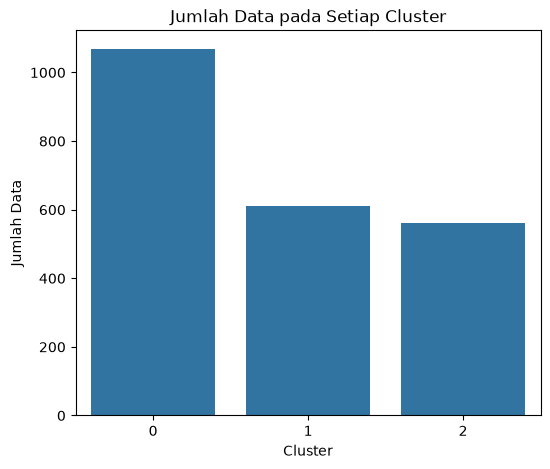

In [33]:
# ==========================================================
# VISUALISASI JUMLAH CLUSTER
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Jumlah Data pada Setiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")

plt.show()

In [37]:
# ==========================================================
# EVALUASI MODEL
# SILHOUETTE SCORE
# ==========================================================

score = silhouette_score(X_scaled, cluster)

print(f"Silhouette Score : {score:.4f}")


#| Nilai       | Kualitas Cluster |
#| ----------- | ---------------- |
#| > 0.70      | Sangat Baik      |
#| 0.50 - 0.70 | Baik             |
#| 0.25 - 0.50 | Cukup            |
#| < 0.25      | Kurang           |


Silhouette Score : 0.2573


In [38]:
# ==========================================================
# REDUKSI DIMENSI MENGGUNAKAN PCA
# ==========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("✓ PCA berhasil dilakukan.")

✓ PCA berhasil dilakukan.


In [39]:
# ==========================================================
# MEMBUAT DATAFRAME PCA
# ==========================================================

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["Cluster"] = cluster

df_pca.head()

,PC1,PC2,Cluster
0,3.796999,-0.870646,2
1,-2.388210,-0.205855,0
2,1.844888,0.171744,1
3,-2.394559,-1.045102,0
4,-0.137299,-0.842572,0


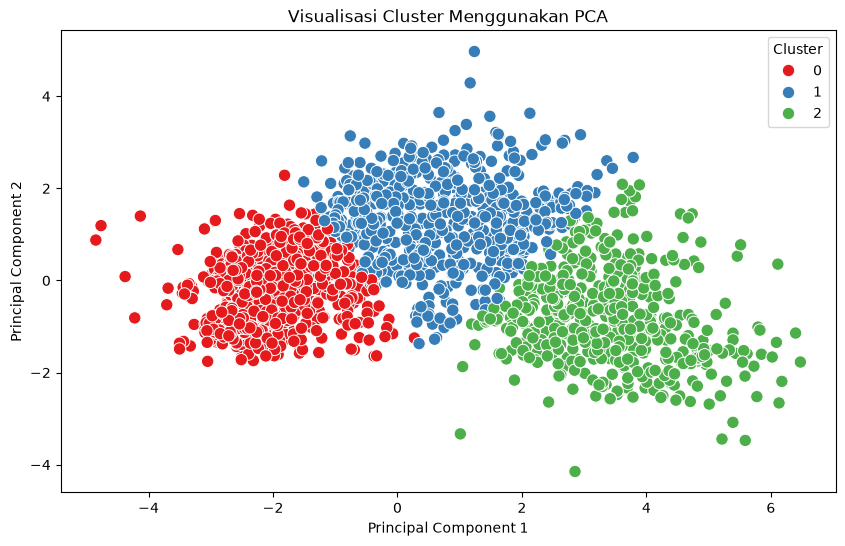

In [40]:
# ==========================================================
# VISUALISASI HASIL CLUSTERING
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Visualisasi Cluster Menggunakan PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

In [41]:
# ==========================================================
# TITIK CENTROID
# ==========================================================

centroid = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

centroid

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,-0.677055,0.678035,-0.094816,0.009501,-0.764012,-0.535168,-0.629254,-0.553593,-0.532612,-0.535497,-0.669300,-0.714682,-0.777580,0.495716
1,0.282563,-0.496838,0.729564,-0.046565,0.537389,-0.092717,-0.118228,-0.134550,-0.085676,0.353895,0.827832,0.182842,0.618463,0.085410
2,0.984153,-0.752234,-0.615010,0.032670,0.872114,1.122758,1.330196,1.203573,1.110196,0.636101,0.374422,1.164783,0.809557,-1.039476


In [42]:
# ==========================================================
# KARAKTERISTIK MASING-MASING CLUSTER
# ==========================================================

cluster_summary = df.groupby("Cluster")[fitur].mean().round(2)

cluster_summary

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,,,,
0,35299.07,0.81,0.45,49.38,46.83,5.02,24.95,7.29,5.08,16.09,2.23,0.57,3.26,6.52
1,59320.42,0.18,0.90,47.76,484.78,22.62,140.27,30.18,23.53,62.48,6.38,3.20,7.80,5.52
2,76882.79,0.04,0.17,50.06,597.42,70.95,467.13,103.26,72.88,77.20,5.12,6.07,8.42,2.79


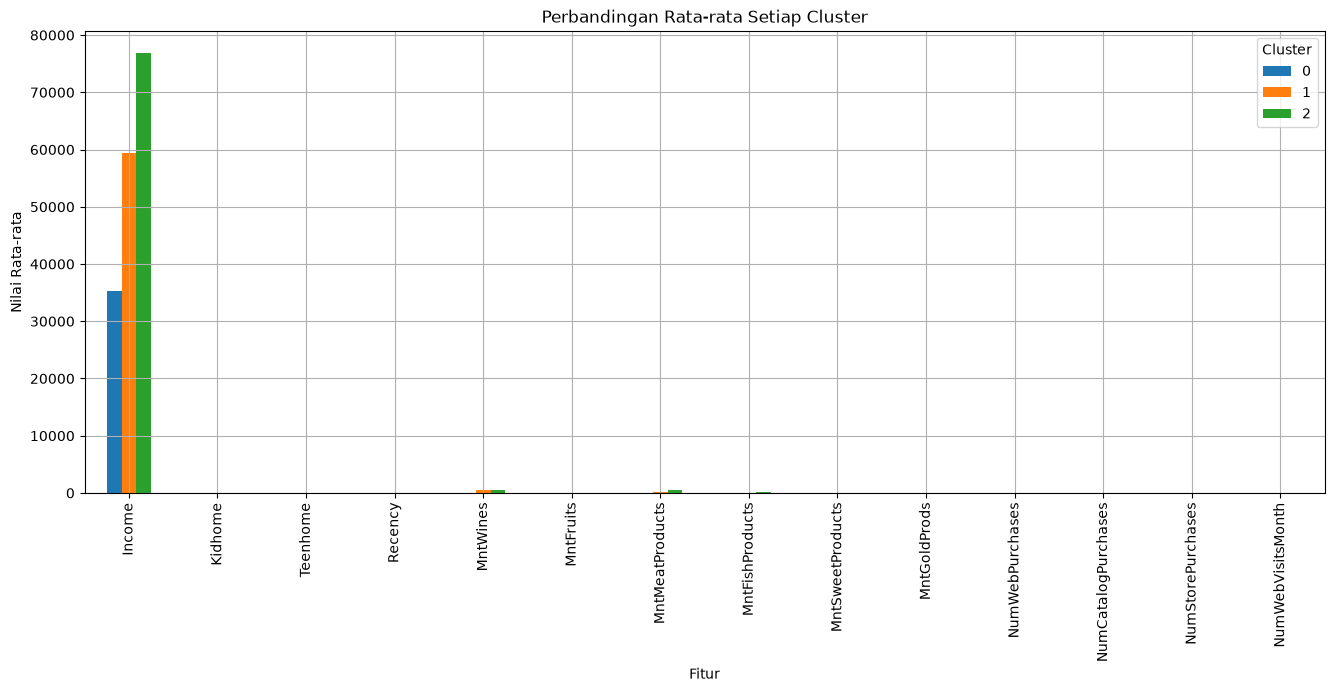

In [43]:
# ==========================================================
# PERBANDINGAN KARAKTERISTIK CLUSTER
# ==========================================================

cluster_summary.T.plot(
    kind="bar",
    figsize=(16,6)
)

plt.title("Perbandingan Rata-rata Setiap Cluster")

plt.xlabel("Fitur")
plt.ylabel("Nilai Rata-rata")

plt.grid(True)

plt.show()

In [44]:
# ==========================================================
# MENYIMPAN HASIL CLUSTERING
# ==========================================================

df.to_csv(
    "output/hasil_clustering.csv",
    index=False
)

print("✓ Hasil clustering berhasil disimpan.")

✓ Hasil clustering berhasil disimpan.


# Kesimpulan

Pada proyek ini dilakukan proses preprocessing terhadap dataset Customer Personality Analysis yang meliputi pengecekan missing value, penanganan missing value menggunakan nilai rata-rata, pengecekan data duplikat, serta normalisasi data menggunakan StandardScaler.

Selanjutnya dilakukan proses clustering menggunakan algoritma K-Means. Jumlah cluster ditentukan menggunakan metode Elbow dan dipilih sebanyak tiga cluster. Hasil clustering kemudian dievaluasi menggunakan Silhouette Score dan divisualisasikan menggunakan Principal Component Analysis (PCA).

Berdasarkan hasil tersebut, data pelanggan berhasil dikelompokkan ke dalam beberapa cluster yang memiliki karakteristik berbeda sehingga dapat digunakan sebagai dasar analisis perilaku pelanggan.